In [18]:
import chess
import numpy as np
import pandas as pd
from IPython.display import display,SVG
board=chess.Board()

In [19]:
def one_hot_encode_piece(piece):
    pieces = list('rnbqkpRNBQKP.')
    arr = np.zeros(len(pieces))
    piece_to_index = {p: i for i, p in enumerate(pieces)}
    index = piece_to_index[piece]
    arr[index] = 1
    return arr



In [20]:
def encode_board(board):
    board_str = str(board)
    board_str = board_str.replace(' ', '')
    board_list = []
    for row in board_str.split('\n'):
        row_list = []
        for piece in row:
            row_list.append(one_hot_encode_piece(piece))
        board_list.append(row_list)
    return np.array(board_list)

encode_board(chess.Board())

array([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

    

In [21]:
train_df = pd.read_csv('train.csv', index_col='id')

# We'll only use the first 10000 examples so things run fast,
# but you'll get better performance if you remove this line
train_df = train_df[:10000]

# We'll also grab the last 1000 examples as a validation set
val_df = train_df[-1000:]
train_df.head()

,board,black_score,best_move
id,,,
80091,6R1/8/5K2/8/5k2/8/8/2r5 w - - 89 118,0.0,g8d8
18578,r1bn1rk1/1p2b1p1/1q2p2p/p2p1p1n/P2P3P/2PB1N2/1...,-131.0,f3e5
11580,r2qkb1r/2p2pp1/p1n2nP1/1p1p3p/P7/1Q5b/1PP1PPB1...,-490.0,g6f7
72805,8/4kp2/R6p/8/4K3/8/8/8 b - - 7 85,-574.0,h6h5
74310,8/8/k7/4R3/8/6K1/8/1r6 w - - 99 90,0.0,e5e6


In [22]:
def encode_fen_string(fen_str):
    board = chess.Board(fen=fen_str)
    return encode_board(board)

X_train = np.stack(train_df['board'].apply(encode_fen_string))
y_train = train_df['black_score']


X_val = np.stack(val_df['board'].apply(encode_fen_string))
y_val = val_df['black_score']


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# With the Keras Sequential model we can stack neural network layers together
model = Sequential([
    Input(shape=(8, 8, 13)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1),
])

model.compile(
    optimizer='rmsprop',
    loss='mean_squared_error')

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val))

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 153975.2656 - val_loss: 140473.1719
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 150555.8750 - val_loss: 136453.5000
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 145744.4531 - val_loss: 132007.4062
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 141065.8906 - val_loss: 128192.1406
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 137136.4844 - val_loss: 125129.2500
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 133882.2656 - val_loss: 122627.5781
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 131100.0156 - val_loss: 120499.6406
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 128648.4453 - val_loss: 118630.3125
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 126440.2969 - val_loss: 116952.3281
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 124423.7188 - val_loss: 115424.3359
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━

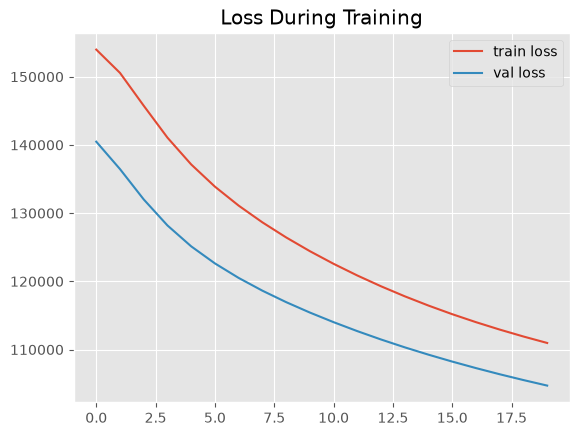

In [25]:
import matplotlib.pyplot as plt

# Lets plot the history of our training session to see how things progressed over time
plt.style.use('ggplot')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss During Training')
plt.show()

In [26]:


def play_nn(fen, show_move_evaluations=False, player='b'):
    board = chess.Board(fen=fen)

    moves = []
    for move in board.legal_moves:
        candidate_board = board.copy()
        candidate_board.push(move)
        input_vector = encode_board(candidate_board).astype(np.float32)


        score = model.predict(np.expand_dims(input_vector, axis=0), verbose=0)[0][0]
        moves.append((score, move))
        if show_move_evaluations:
            print(f'{move}: {score}')

    best_move = sorted(moves, reverse=player=='b')[0][1]

    return str(best_move)


In [27]:
def play_game(function):
    board=chess.Board()
    while board.outcome() is None:
        display(SVG(board._repr_svg_()))
        if board.turn == chess.WHITE:
            user_move=input("Enter your move: ")
            if user_move.lower() == "quit":
                print(f"Legal moves: {[str(move) for move in board.legal_moves]}")
                print("Game Over! You lose.")
                break
            while user_move not in [str(move) for move in board.legal_moves]:
                print("Invalid move. Please try again.")
                user_move=input("Enter your move: ")
            board.push(chess.Move.from_uci(user_move))
        elif board.turn == chess.BLACK:
            move=function(board.fen())
            print(f"Computer plays: {move}")
            board.push(chess.Move.from_uci(move))
    if board.outcome() is not None:
        display(SVG(board._repr_svg_()))
        print("Game Over!")
        print(f"Result: {board.outcome().result()}")


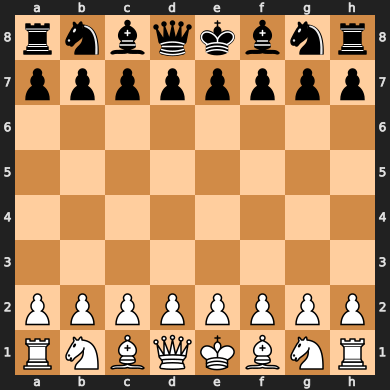

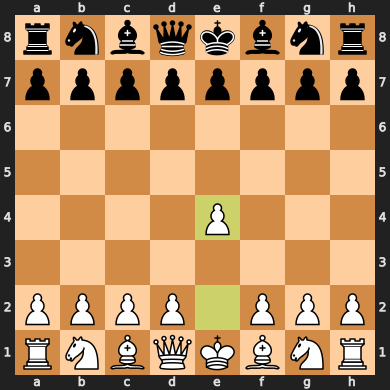

Computer plays: d7d5


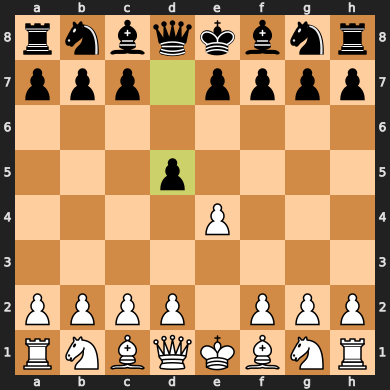

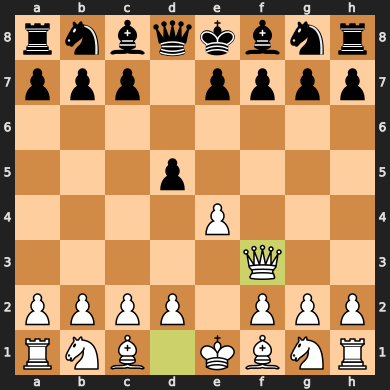

Computer plays: d5e4


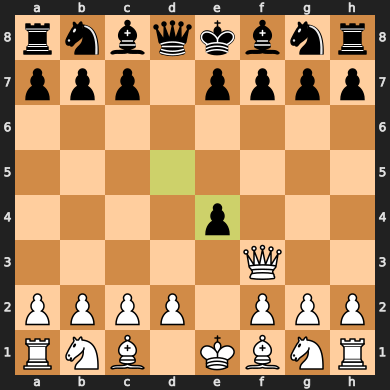

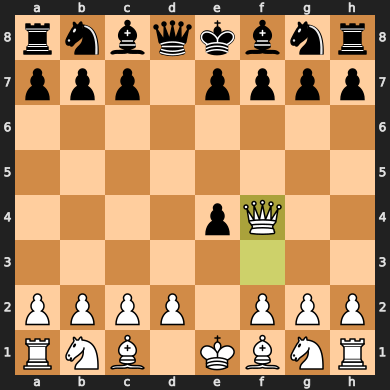

Computer plays: b8c6


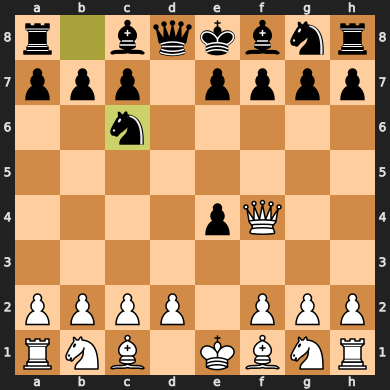

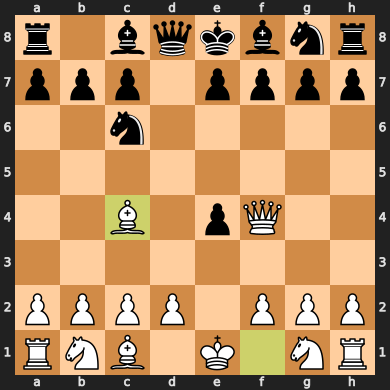

Computer plays: e4e3


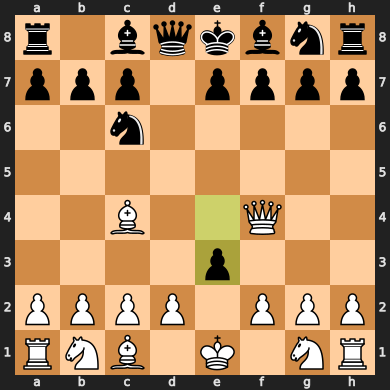

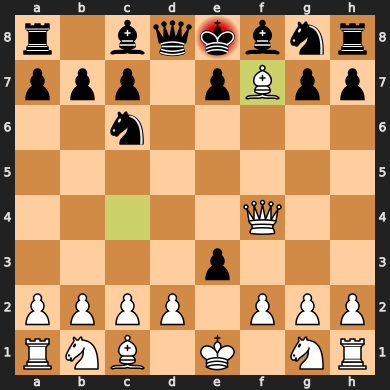

Computer plays: e8d7


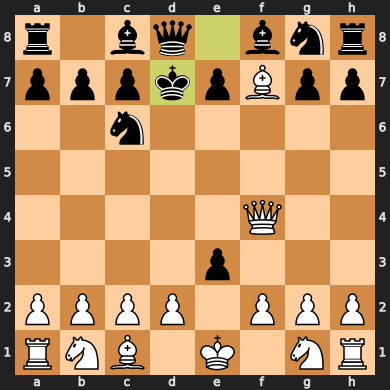

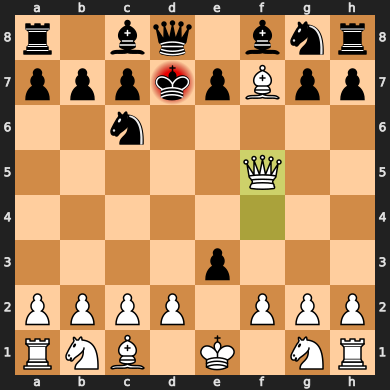

Computer plays: e7e6


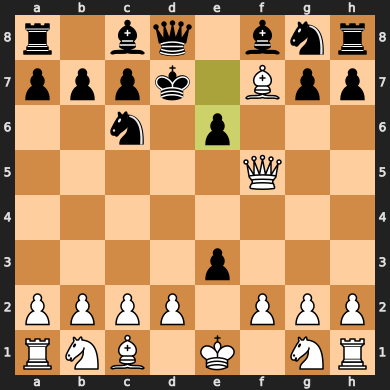

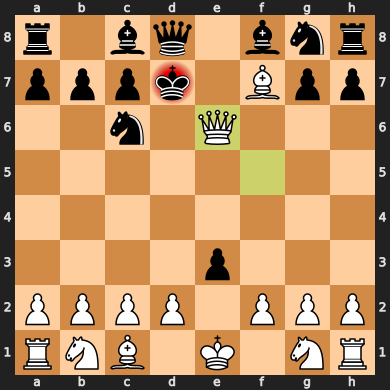

Game Over!
Result: 1-0


In [28]:
play_game(play_nn)